# EDA — Previsão de Evasão Estudantil

Análise exploratória que fundamenta o pipeline (`src/`). Foco em: distribuição do alvo, qualidade dos dados (o reparo das notas) e sinal preditivo das principais variáveis.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data
from src.features import _repair_grade, GradeRepairTransformer
from src.config import GRADE_COLUMNS

df = load_data()
df.shape

(4423, 28)

## 1. Alvo e balanceamento

O `Target` tem 3 classes; o trabalho é binário, então tratamos `Desistente` como classe positiva (evasão).

In [2]:
print(df['Target'].value_counts())
dropout_rate = (df['Target'] == 'Desistente').mean()
print(f'\nTaxa de evasao (Desistente): {dropout_rate:.1%}')

Target
Graduado       2209
Desistente     1420
Matriculado     794
Name: count, dtype: int64

Taxa de evasao (Desistente): 32.1%


## 2. Integridade básica

In [3]:
print('Valores ausentes:', int(df.isna().sum().sum()))
print('Linhas duplicadas:', int(df.duplicated().sum()))

Valores ausentes: 0
Linhas duplicadas: 0


## 3. Qualidade dos dados — notas corrompidas

As notas deveriam estar em [0, 20], mas ~40% dos valores têm o ponto decimal deslocado (ex.: `13.43` vira `1.34e16` ou `13875`).

In [4]:
col = GRADE_COLUMNS[0]
corrupted = df[df[col] > 20]
print(f'{col}: {len(corrupted)} de {len(df)} valores > 20 ({len(corrupted)/len(df):.0%})')
print('Exemplos de valores corrompidos:')
print(corrupted[col].head(5).tolist())

UnidadesCurriculares1SemestreGrau: 1790 de 4423 valores > 20 (40%)
Exemplos de valores corrompidos:
[1.34285714285714e+16, 1.23333333333333e+16, 1.18571428571428e+16, 13875.0, 1.23333333333333e+16]


In [5]:
# Demonstração da regra de reparo: dividir por 10 até cair em [0, 20]
exemplos = [1.34285714285714e16, 13875.0, 14545.0, 13.4, 0.0]
for v in exemplos:
    print(f'{v:>22} -> {_repair_grade(v):.4f}')

  1.34285714285714e+16 -> 13.4286
               13875.0 -> 13.8750
               14545.0 -> 14.5450
                  13.4 -> 13.4000
                   0.0 -> 0.0000


In [6]:
# Após o reparo, todos os valores caem em [0, 20] e sem casos ambíguos em (20, 200]
repaired = GradeRepairTransformer().transform(df[GRADE_COLUMNS])
print('Min/Max apos reparo:')
print(repaired.agg(['min', 'max']).T)
ambiguos = ((df[GRADE_COLUMNS] > 20) & (df[GRADE_COLUMNS] <= 200)).sum().sum()
print('\nCasos ambiguos em (20, 200]:', int(ambiguos))

Min/Max apos reparo:
                                   min        max
UnidadesCurriculares1SemestreGrau  0.0  18.875000
UnidadesCurriculares2SemestreGrau  0.0  18.571429

Casos ambiguos em (20, 200]: 0


## 4. Sinal preditivo

Variáveis financeiras e de desempenho separam fortemente os desfechos.

In [7]:
d = df.copy()
d['Evasao'] = (d['Target'] == 'Desistente').astype(int)
for c in ['Devedor', 'MensalidadesEmDia', 'Bolsista', 'Genero']:
    print(c, d.groupby(c)['Evasao'].mean().round(3).to_dict())

Devedor {0: 0.283, 1: 0.62}
MensalidadesEmDia {0: 0.866, 1: 0.247}
Bolsista {0: 0.387, 1: 0.122}
Genero {'Feminino': 0.251, 'Masculino': 0.45}


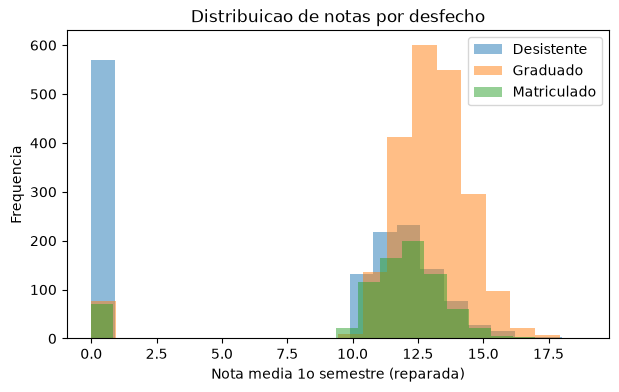

Nota media por desfecho:
Target
Desistente      7.26
Graduado       12.64
Matriculado    11.13
Name: Nota1, dtype: float64


In [8]:
d['Nota1'] = repaired[GRADE_COLUMNS[0]]
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in d.groupby('Target'):
    ax.hist(grp['Nota1'], bins=20, alpha=0.5, label=label)
ax.set_xlabel('Nota media 1o semestre (reparada)')
ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao de notas por desfecho')
ax.legend()
plt.show()

print('Nota media por desfecho:')
print(d.groupby('Target')['Nota1'].mean().round(2))

## 5. Conclusões

- Dados limpos exceto pela corrupção das notas, resolvida por regra determinística (ver `GradeRepairTransformer`).
- Sinal forte e intuitivo (situação financeira + desempenho acadêmico).
- O pipeline completo (feature engineering, modelagem, validação cruzada, SHAP) está em `src/` e é treinado com `python -m src.train`. Ver `docs/analysis.md` para resultados e análise de over/underfitting.